# Exploratory Data Analysis (EDA)

## Objective
The goal of this analysis is to explore the distributional differences between households that fall into the SNAP participation gap (`TARGET_GAP = 1`) and those that do not (`TARGET_GAP = 0`). 

In particular, we aim to understand how key household characteristics (X variables) differ across these two groups. These differences can provide insights into structural and socioeconomic factors associated with the gap population.

---

## Approach
We divide the dataset into two groups:
- **Gap Group (TARGET_GAP = 1):** Households that are likely eligible but not receiving SNAP benefits.
- **Non-Gap Group (TARGET_GAP = 0):** Households that are not in the gap.

To compare these groups, we analyze the distribution of selected variables using:
- **Histograms** to visualize distribution overlap
- **Boxplots** to highlight differences in central tendency and spread

---

## Variables of Interest
The analysis focuses on key variables that capture household structure, economic pressure, and access to resources:

- **NUM_CHILDREN:** Number of children in the household  
- **VEH:** Number of vehicles (proxy for mobility/access)  
- **RENT_BURDEN:** Housing cost pressure relative to income  
- **HOUSEHOLD_PRESSURE:** Composite indicator of financial stress  
- **PERSONS_PER_ROOM:** Measure of overcrowding  

---

## Expected Insights
Through this analysis, we aim to identify patterns such as:
- Whether gap households experience higher financial stress  
- Differences in family size and dependency burden  
- Potential access limitations (e.g., transportation, housing conditions)

These insights will help guide further modeling and policy-oriented analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load file
df= pd.read_csv("../data/processed/processed_all_households_blind.csv")

In [2]:
df.info()
df.describe()
df.isnull().mean().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 7450 entries, 0 to 7449
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SERIALNO                     7450 non-null   str    
 1   PUMA                         7450 non-null   int64  
 2   TARGET_GAP                   7450 non-null   int64  
 3   HAS_ELDERLY                  7450 non-null   int64  
 4   HAS_DISABLED                 7450 non-null   int64  
 5   NUM_CHILDREN                 7450 non-null   int64  
 6   NUM_WORKING_ADULTS           7450 non-null   int64  
 7   MAX_EDUCATION                7450 non-null   float64
 8   IS_MINORITY_HH               7450 non-null   int64  
 9   VEH                          7450 non-null   float64
 10  ACCESSINET                   7450 non-null   float64
 11  GRPIP                        7450 non-null   float64
 12  RMSP                         7450 non-null   float64
 13  NP                           

SERIALNO                       0.0
INTERNET_DEVICE_INTERACTION    0.0
WEALTH_INCOME_RATIO            0.0
RENT_INCOME_INTERACTION        0.0
WORKERS_INCOME_INTERACTION     0.0
HOUSEHOLD_PRESSURE             0.0
DEVICE_COUNT                   0.0
SMARTPHONE_ONLY                0.0
HOUSING_QUALITY_INDEX          0.0
IS_OWNER                       0.0
AMENITY_COUNT                  0.0
LOW_AMENITIES                  0.0
LIMITED_ENGLISH                0.0
ENGLISH_ONLY                   0.0
PERSONS_PER_ROOM               0.0
CROWDED_HH                     0.0
WORKERS_PC                     0.0
POVERTY_GAP                    0.0
PUMA                           0.0
IS_MINORITY_HH                 0.0
TARGET_GAP                     0.0
HAS_ELDERLY                    0.0
HAS_DISABLED                   0.0
NUM_CHILDREN                   0.0
NUM_WORKING_ADULTS             0.0
MAX_EDUCATION                  0.0
VEH                            0.0
RENT_BURDEN                    0.0
ACCESSINET          

### 2. Split the groups

In [7]:
df_gap = df[df['TARGET_GAP'] == 1]
df_non_gap = df[df['TARGET_GAP'] == 0]


## Number of Children

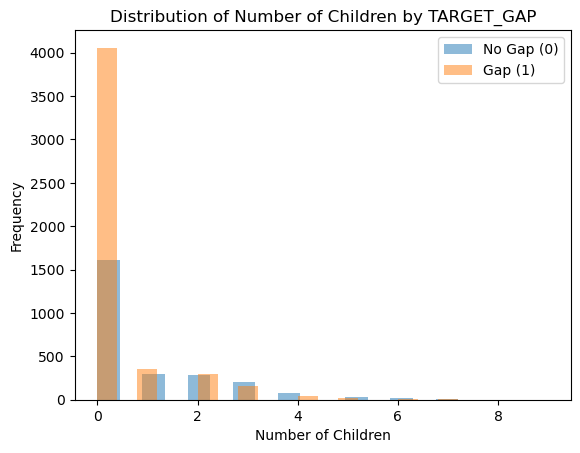

In [8]:
plt.figure()

plt.hist(df_non_gap['NUM_CHILDREN'], bins=20, alpha=0.5, label='No Gap (0)')
plt.hist(df_gap['NUM_CHILDREN'], bins=20, alpha=0.5, label='Gap (1)')

plt.xlabel('Number of Children')
plt.ylabel('Frequency')
plt.title('Distribution of Number of Children by TARGET_GAP')
plt.legend()

plt.show()

### Number of Children

The distribution of the number of children indicates that households in the **TARGET_GAP = 1** group tend to have slightly larger family sizes compared to non-gap households.

This pattern suggests that households with more dependents may face increased financial pressure, which could contribute to their likelihood of falling into the SNAP participation gap.

Larger household size may therefore be an important factor in understanding unmet assistance needs.

## Rent

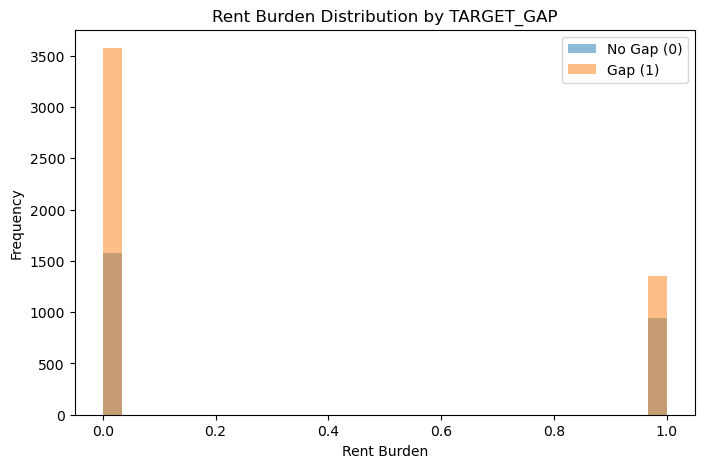

In [11]:


plt.figure(figsize=(8,5))

plt.hist(df_non_gap['RENT_BURDEN'].dropna(), bins=30, alpha=0.5, label='No Gap (0)')
plt.hist(df_gap['RENT_BURDEN'].dropna(), bins=30, alpha=0.5, label='Gap (1)')

plt.xlabel('Rent Burden')
plt.ylabel('Frequency')
plt.title('Rent Burden Distribution by TARGET_GAP')
plt.legend()

plt.show()

### Rent Burden Analysis

The distribution of rent burden shows a clear difference between the two groups. Households in the **TARGET_GAP = 1** group tend to experience higher rent burden compared to those in the non-gap group.

This suggests that gap households face greater housing cost pressure relative to their income. Additionally, the wider spread of the distribution indicates variability in financial stress within this group.

Overall, higher rent burden appears to be a strong indicator associated with households that are eligible but not receiving SNAP benefits.

## VEH (Number of Cars)

In [15]:
df['HAS_CAR'] = (df['VEH'] > 0).astype(int)

### Has Car or No

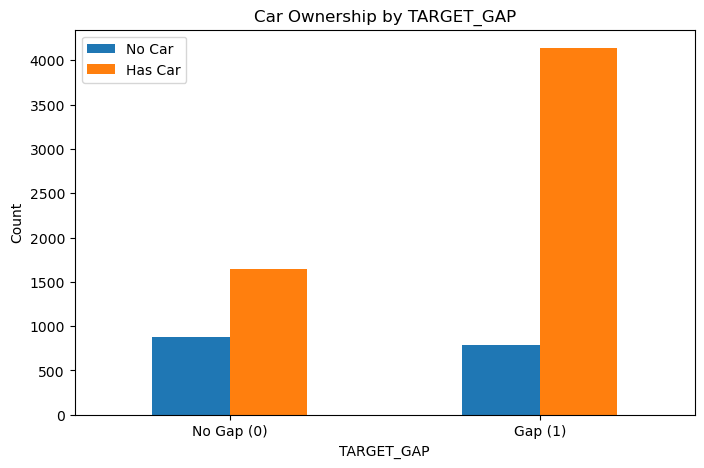

In [16]:
car_counts = df.groupby(['TARGET_GAP', 'HAS_CAR']).size().unstack(fill_value=0)

car_counts.plot(kind='bar', figsize=(8,5))
plt.xlabel('TARGET_GAP')
plt.ylabel('Count')
plt.title('Car Ownership by TARGET_GAP')
plt.xticks([0,1], ['No Gap (0)', 'Gap (1)'], rotation=0)
plt.legend(['No Car', 'Has Car'])
plt.show()

### Vehicle Ownership

The distribution of vehicle ownership shows that households in the **TARGET_GAP = 1** group generally have fewer vehicles compared to non-gap households.

This may indicate limited transportation access, which could act as a barrier to accessing resources, including SNAP enrollment services.

Lower vehicle ownership may therefore be associated with reduced mobility and increased vulnerability among gap households.

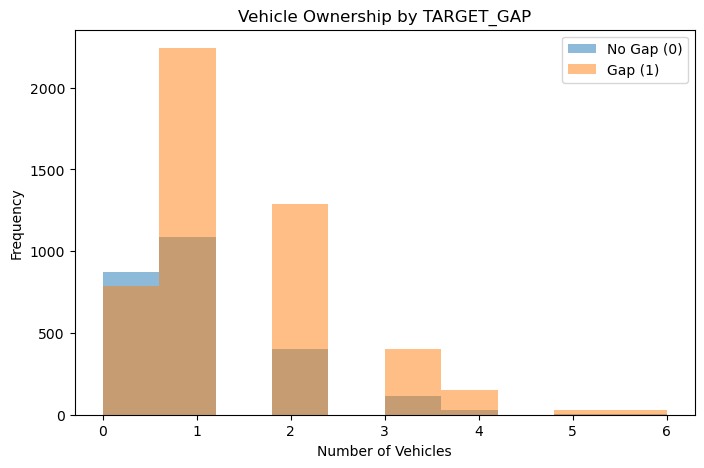

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df_non_gap['VEH'].dropna(), bins=10, alpha=0.5, label='No Gap (0)')
plt.hist(df_gap['VEH'].dropna(), bins=10, alpha=0.5, label='Gap (1)')

plt.xlabel('Number of Vehicles')
plt.ylabel('Frequency')
plt.title('Vehicle Ownership by TARGET_GAP')
plt.legend()

plt.show()

## Household Pressure

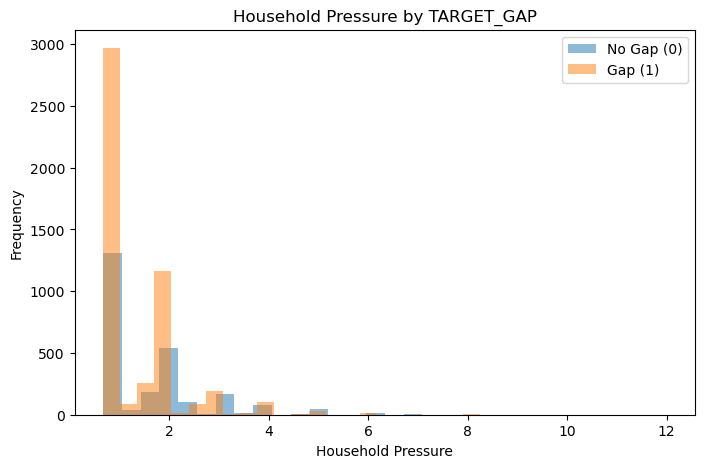

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df_non_gap['HOUSEHOLD_PRESSURE'].dropna(), bins=30, alpha=0.5, label='No Gap (0)')
plt.hist(df_gap['HOUSEHOLD_PRESSURE'].dropna(), bins=30, alpha=0.5, label='Gap (1)')

plt.xlabel('Household Pressure')
plt.ylabel('Frequency')
plt.title('Household Pressure by TARGET_GAP')
plt.legend()

plt.show()

### Household Pressure

The distribution of the household pressure variable reveals that **TARGET_GAP = 1** households tend to experience higher overall pressure compared to non-gap households.

This suggests that gap households face compounded socioeconomic stress, potentially combining factors such as income constraints, household size, and resource limitations.

This variable provides a strong aggregated signal of vulnerability and is highly informative for distinguishing gap households.

## PERSONS_PER_ROOM

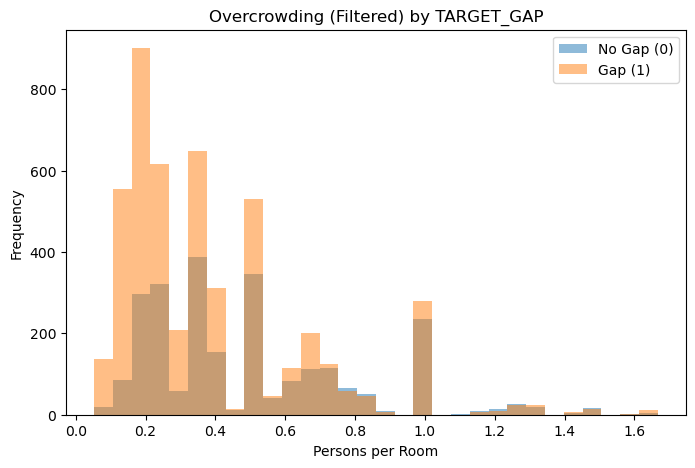

In [17]:
import numpy as np

# remove extreme outliers (top 1%)
threshold = df['PERSONS_PER_ROOM'].quantile(0.99)

df_filtered = df[df['PERSONS_PER_ROOM'] <= threshold]

df_gap_f = df_filtered[df_filtered['TARGET_GAP'] == 1]
df_non_gap_f = df_filtered[df_filtered['TARGET_GAP'] == 0]

plt.figure(figsize=(8,5))

plt.hist(df_non_gap_f['PERSONS_PER_ROOM'], bins=30, alpha=0.5, label='No Gap (0)')
plt.hist(df_gap_f['PERSONS_PER_ROOM'], bins=30, alpha=0.5, label='Gap (1)')

plt.xlabel('Persons per Room')
plt.ylabel('Frequency')
plt.title('Overcrowding (Filtered) by TARGET_GAP')
plt.legend()

plt.show()